# **Credit Risk Prediction**
**Introduction**

Credit risk prediction is a key task in financial analytics. The objective of this assignment is to preprocess a credit risk dataset and prepare it for machine learning models that can predict whether a borrower is likely to default.

This study covers:

Data loading and inspection

Data cleaning and preprocessing

Feature encoding and scaling

Train-test split





**RESEARCH AIM**

The primary aim of this research is to develop and evaluate machine learning models for predicting credit risk and to compare their performance against traditional statistical methods.

 **Problem Statement**

Financial institutions must accurately estimate the probability of default for loan applicants using limited information available at loan origination. Poor prediction can result in increased default rates or overly conservative lending policies.

In [ ]:
#importing python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
#loading dataset
df=pd.read_csv('/content/credit_risk_dataset.csv')


In [ ]:
#printing first 5 rows
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
#printing last 5 rows
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [ ]:
#printing no.of rows and columns
df.shape

(32581, 12)

In [ ]:
#printing datatypes and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [ ]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [ ]:
#checking for missing values
df.isnull().sum()


,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [ ]:

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_count,
    "Percentage (%)": missing_percentage
})

missing_df[missing_df["Missing Values"] > 0]


,Missing Values,Percentage (%)
person_emp_length,895,2.747000
loan_int_rate,3116,9.563856


In [ ]:
#fixing missing values
from sklearn.impute import SimpleImputer

# Define numerical columns with missing values for imputation
num_cols = ['person_emp_length', 'loan_int_rate']

# Numerical imputation
num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [ ]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


### **EXPLORATORY DATA ANALYSIS**

Exploratory Data Analysis (EDA) is a critical step in the data science process that involves examining and summarizing the main characteristics of a dataset before building predictive models. In this study, EDA was conducted to understand the structure, distribution, and relationships within the credit risk dataset, with particular focus on identifying patterns associated with loan default. The analysis includes univariate, bivariate, and multivariate techniques to detect trends, outliers, class imbalance, and potential correlations among variables.

Through graphical visualization and statistical summaries, EDA helps assess data quality, identify preprocessing requirements, and provide insights into the factors influencing credit risk. The findings from this stage form the foundation for feature engineering and machine learning model development in subsequent chapters.

## **UNIVARIATE ANALYSIS**

Univariate analysis examines one variable at a time to understand its distribution, central tendency, and variability.

1️ Distribution of Borrower Age

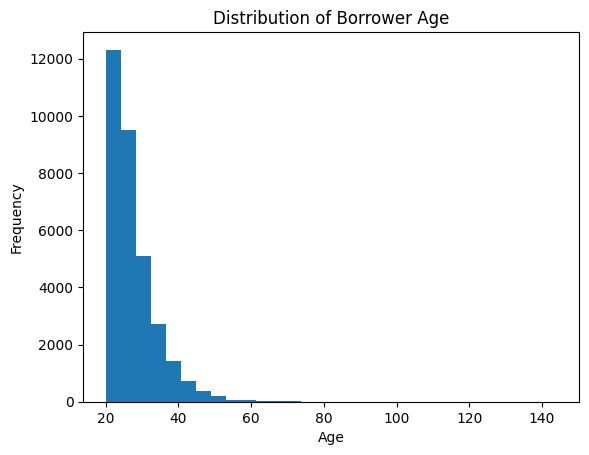

In [ ]:
plt.figure()
plt.hist(df['person_age'], bins=30)
plt.title("Distribution of Borrower Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


2️. Distribution of Annual Income

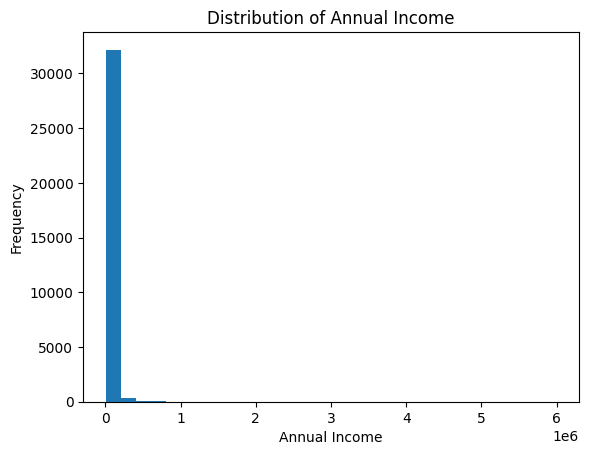

In [ ]:
plt.figure()
plt.hist(df['person_income'], bins=30)
plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.show()


3️. Distribution of Loan Amount

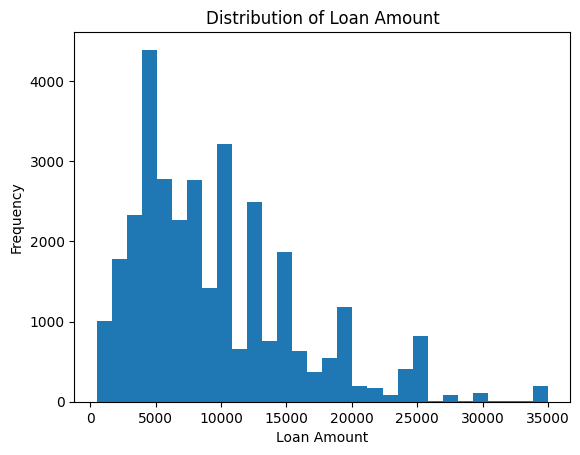

In [ ]:
plt.figure()
plt.hist(df['loan_amnt'], bins=30)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()


4️. Boxplot of Interest Rate

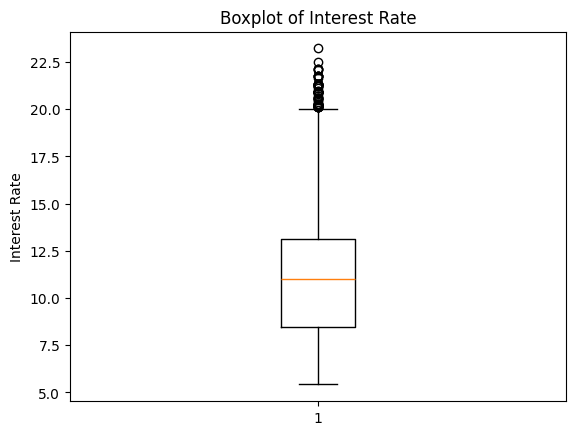

In [ ]:
plt.figure()
plt.boxplot(df['loan_int_rate'].dropna())
plt.title("Boxplot of Interest Rate")
plt.ylabel("Interest Rate")
plt.show()


5️. Distribution of Loan Percent Income

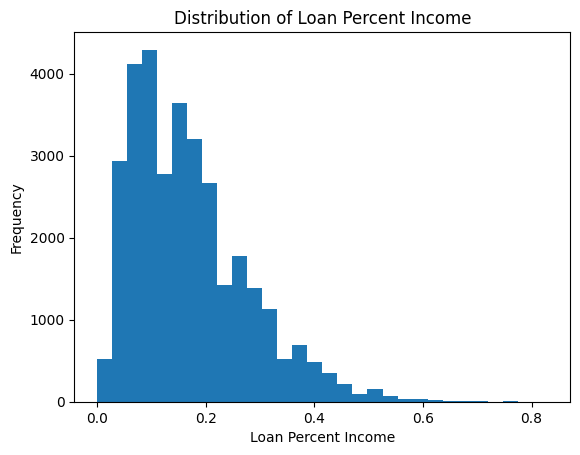

In [ ]:
plt.figure()
plt.hist(df['loan_percent_income'], bins=30)
plt.title("Distribution of Loan Percent Income")
plt.xlabel("Loan Percent Income")
plt.ylabel("Frequency")
plt.show()


6️. Home Ownership Distribution

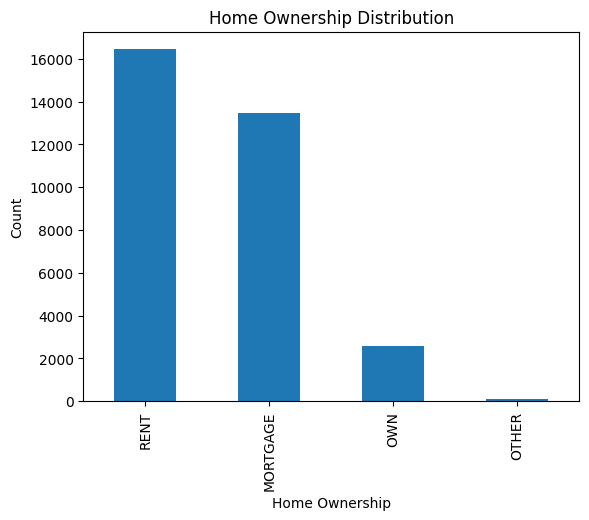

In [ ]:
plt.figure()
df['person_home_ownership'].value_counts().plot(kind='bar')
plt.title("Home Ownership Distribution")
plt.xlabel("Home Ownership")
plt.ylabel("Count")
plt.show()

7️. Loan Intent Distribution

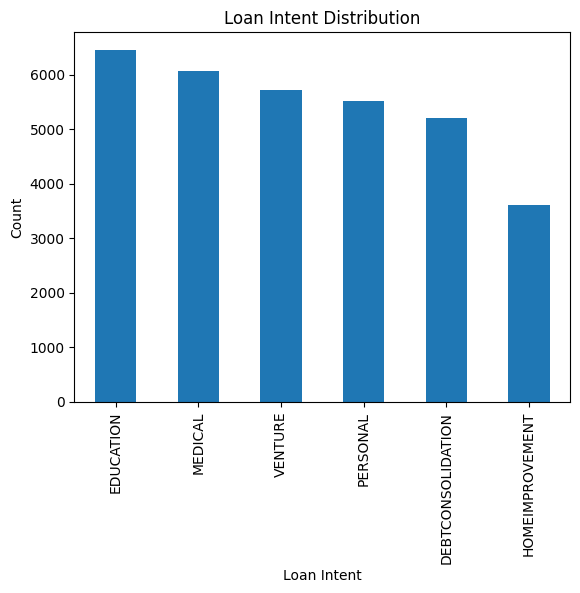

In [ ]:
plt.figure()
df['loan_intent'].value_counts().plot(kind='bar')
plt.title("Loan Intent Distribution")
plt.xlabel("Loan Intent")
plt.ylabel("Count")
plt.show()

8️. Loan Grade Distribution

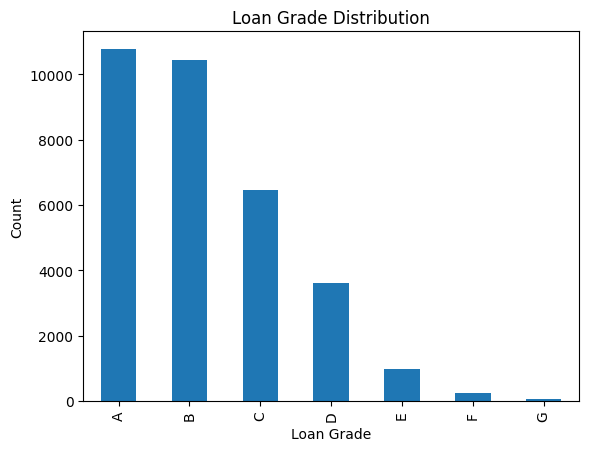

In [ ]:
plt.figure()
df['loan_grade'].value_counts().plot(kind='bar')
plt.title("Loan Grade Distribution")
plt.xlabel("Loan Grade")
plt.ylabel("Count")
plt.show()

9️. Loan Status Distribution

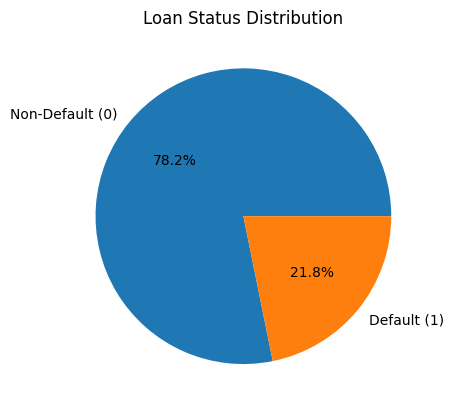

In [ ]:
loan_status_counts = df['loan_status'].value_counts()
plt.figure()
plt.pie(loan_status_counts,
        labels=['Non-Default (0)', 'Default (1)'],
        autopct='%1.1f%%')

plt.title("Loan Status Distribution")
plt.show()

1️ **Distribution of Borrower Age**

This histogram shows the age distribution of borrowers.

Most borrowers fall between their early 20s and early 30s. The distribution is slightly right-skewed, meaning there are fewer older applicants. A few extreme values (very high ages) may represent data entry errors or outliers.

**Interpretation:**
The dataset primarily represents young, working-age individuals who are more likely to seek loans.

2️. **Distribution of Annual Income**

This histogram illustrates borrower income levels.

The income distribution is heavily right-skewed. Most borrowers earn moderate incomes, while a small number earn extremely high incomes.

**Interpretation:**
High-income outliers increase variability. Since income directly affects repayment capacity, transformation (e.g., log transformation) may be required during preprocessing.

3️. **Distribution of Loan Amount**

This chart displays the spread of loan amounts issued.

Loan amounts vary widely, but most are concentrated in the lower-to-mid range. Some high loan values appear as outliers.

**Interpretation:**
Although large loans increase exposure risk, repayment risk depends more on income proportion than absolute loan size.

4️. **Boxplot of Interest Rate**

This boxplot summarizes interest rate spread and variability.

The median interest rate is around the middle of the distribution. There are several upper outliers representing higher-risk borrowers charged higher interest rates.

**Interpretation:**
Interest rate variation suggests risk-based pricing. Outliers may correspond to borrowers with weaker credit profiles.

5️. **Distribution of Loan Percent Income**

This histogram shows the proportion of income allocated to loan repayment.

Most borrowers allocate a small percentage of their income to loan repayment. However, some borrowers have very high ratios.

**Interpretation:**
Higher loan-to-income ratios may indicate financial stress and increased probability of default.

6️.** Home Ownership Distribution**

This bar chart presents borrower housing status.

Most borrowers either rent or have a mortgage. Very few fall into the “other” category.

**Interpretation:**
Housing status may influence financial stability. Renters may have different risk profiles compared to homeowners.

**7️. Loan Intent Distribution**

This chart shows the purpose of loans.

Loans are distributed across categories such as education, medical, venture, personal, debt consolidation, and home improvement. Some purposes appear more common than others.

Interpretation:
Loan purpose may influence default behavior, as certain loan types (e.g., medical or venture) may carry higher uncertainty.

**8️. Loan Grade Distribution**

This bar chart represents internal loan grading.

Most loans are concentrated in grades A, B, and C. Very few loans fall into lower grades (E, F, G).

**Interpretation:**
The majority of borrowers are classified as lower-risk. Lower grades represent higher credit risk and are less frequent.

**9. Loan Status Distribution**

The pie chart illustrates the proportion of defaulted and non-defaulted loans in the dataset.

**Interpretation:**
This indicates that the dataset is imbalanced, with significantly more non-default cases than defaults. Class imbalance must be addressed during model training to avoid biased predictions toward the majority class.

### **BIVARIATE ANALYSIS**

Bivariate analysis examines the relationship between two variables, particularly between independent variables and the target variable (loan_status).

1. Income vs Loan Amount (Scatter)

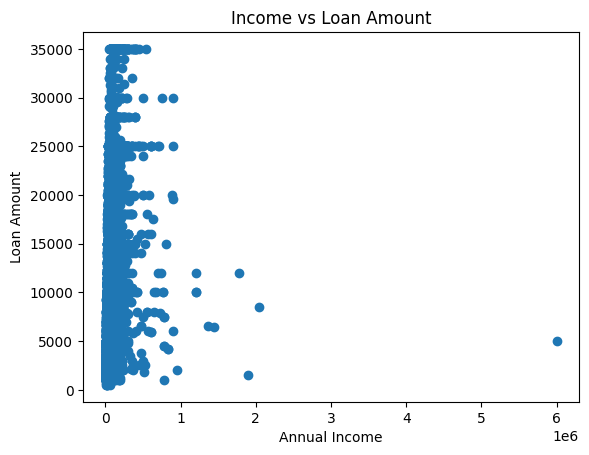

In [ ]:
plt.figure()
plt.scatter(df['person_income'], df['loan_amnt'])
plt.title("Income vs Loan Amount")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.show()

2. Interest Rate vs Loan Status (Boxplot)

<Figure size 640x480 with 0 Axes>

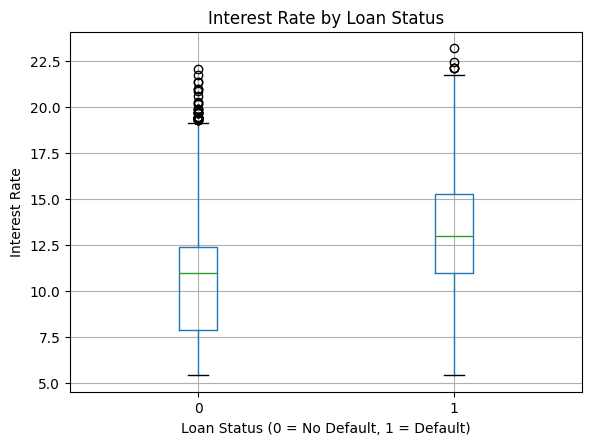

In [ ]:
plt.figure()
df.boxplot(column='loan_int_rate', by='loan_status')
plt.title("Interest Rate by Loan Status")
plt.suptitle("")
plt.xlabel("Loan Status (0 = No Default, 1 = Default)")
plt.ylabel("Interest Rate")
plt.show()


3.Loan grade vs Loan status

<Figure size 640x480 with 0 Axes>

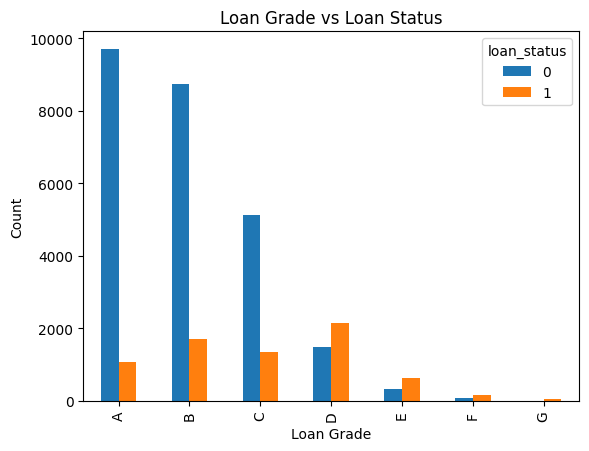

In [ ]:
plt.figure()
pd.crosstab(df['loan_grade'], df['loan_status']).plot(kind='bar')
plt.title("Loan Grade vs Loan Status")
plt.xlabel("Loan Grade")
plt.ylabel("Count")
plt.show()

4. Credit History Length vs Loan Status

<Figure size 640x480 with 0 Axes>

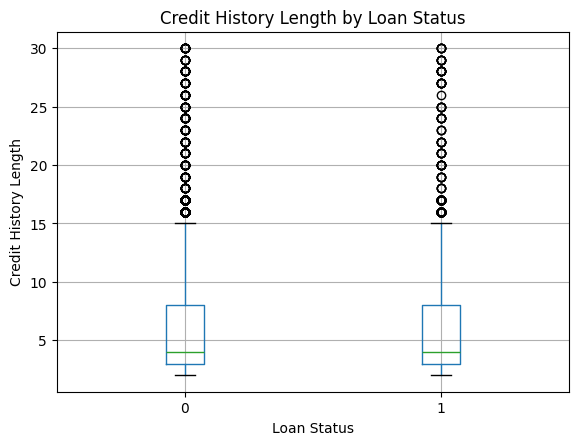

In [ ]:
plt.figure()
df.boxplot(column='cb_person_cred_hist_length', by='loan_status')
plt.title("Credit History Length by Loan Status")
plt.suptitle("")
plt.xlabel("Loan Status")
plt.ylabel("Credit History Length")
plt.show()


5. Income vs Loan Status

<Figure size 640x480 with 0 Axes>

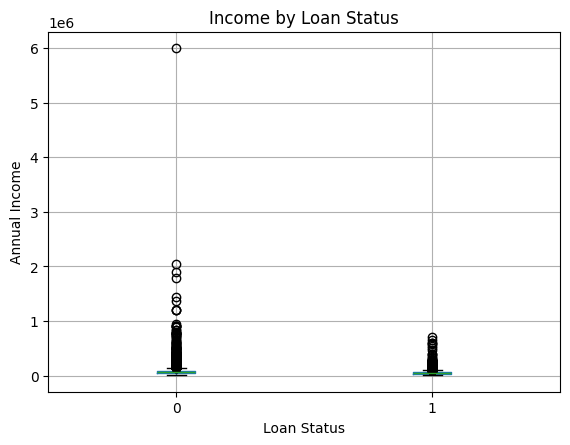

In [ ]:
plt.figure()
df.boxplot(column='person_income', by='loan_status')
plt.title("Income by Loan Status")
plt.suptitle("")
plt.xlabel("Loan Status")
plt.ylabel("Annual Income")
plt.show()

1️. Income vs Loan Amount (Scatter Plot)

The scatter plot shows a positive relationship between annual income and loan amount. Borrowers with higher income levels tend to receive larger loan amounts.

Interpretation:
Lenders appear to consider repayment capacity when approving loan size. However, some borrowers with moderate income still take relatively high loans, which could increase default risk.

2.Interest Rate vs Loan Status (Boxplot)

The boxplot shows that defaulted loans (loan_status = 1) generally have a higher median interest rate than non-defaulted loans (loan_status = 0).

Interpretation:
Higher interest rates are typically assigned to riskier borrowers. The observed pattern suggests that interest rate is positively associated with default risk.

This variable is likely one of the strongest predictors of default.

3. Loan Grade vs Loan Status (Bar Chart)

Default frequency increases as loan grade moves from A (low risk) to lower grades (higher risk categories).

Interpretation:
Loan grading appears to effectively classify borrower risk. Lower grades are associated with higher default rates, validating the grading system.

4.Credit History Length vs Loan Status (Boxplot)

Description:
Borrowers with shorter credit history lengths show slightly higher default tendencies compared to those with longer histories.

Interpretation:
A longer credit history provides more reliable information about repayment behavior, reducing uncertainty and default probability.

5. Income vs Loan Status (Boxplot)

Description:
Non-defaulted borrowers generally have slightly higher median income than defaulted borrowers, though overlap exists.

Interpretation:
Higher income reduces default risk, but income alone is not sufficient to determine repayment behavior.

## **Multivariate Analysis**

Multivariate analysis examines the interaction among three or more variables simultaneously.

1.Correlation Heatmap (Manual using matplotlib)

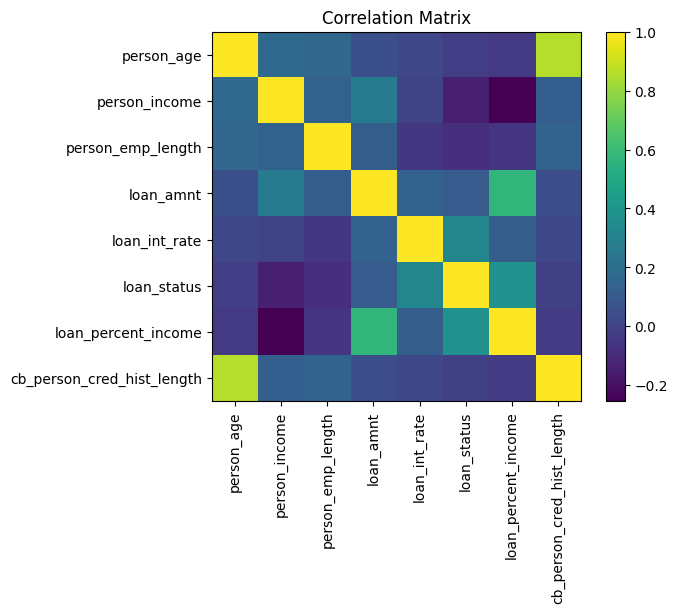

In [ ]:
plt.figure()
corr = df.corr(numeric_only=True)
plt.imshow(corr)
plt.title("Correlation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.show()

2.Income, Loan Amount, Default (Scatter grouped)

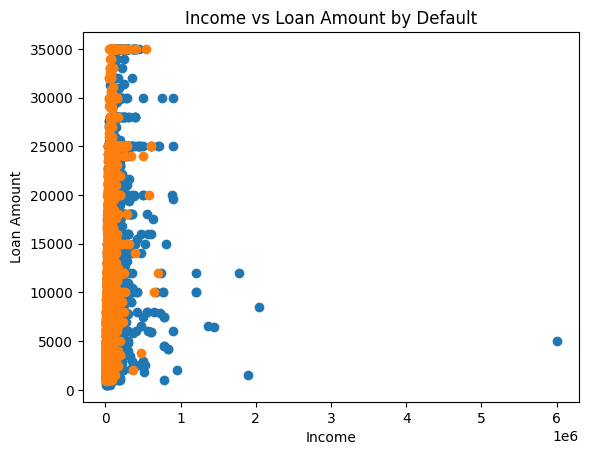

In [ ]:
plt.figure()
default_0 = df[df['loan_status'] == 0]
default_1 = df[df['loan_status'] == 1]

plt.scatter(default_0['person_income'], default_0['loan_amnt'])
plt.scatter(default_1['person_income'], default_1['loan_amnt'])
plt.title("Income vs Loan Amount by Default")
plt.xlabel("Income")
plt.ylabel("Loan Amount")
plt.show()

**1.Correlation Matrix (Heatmap)**


The correlation matrix illustrates the strength and direction of linear relationships among all numerical variables in the dataset. The values range from -1 to +1, where:

+1 indicates strong positive correlation

-1 indicates strong negative correlation

0 indicates no linear relationship

Key Observations:

A positive correlation exists between loan amount and income, indicating that higher-income borrowers tend to receive larger loans.

Loan percent income shows association with default-related behavior.

Interest rate and loan grade may show moderate correlation, suggesting potential multicollinearity.

**interpretation:**
The correlation matrix helps identify redundant variables and potential multicollinearity issues. Highly correlated predictors may distort model performance and should be evaluated using Variance Inflation Factor (VIF) before modeling.

**2.Income vs Loan Amount by Default Status (Grouped Scatter Plot)**

This scatter plot displays the relationship between income and loan amount while distinguishing borrowers by default status.

Key Observations:

Non-default borrowers (loan_status = 0) are more widely distributed across income levels.

Default borrowers (loan_status = 1) appear more concentrated in moderate-income and relatively higher loan regions.

Some default cases show high loan amounts relative to income.

**Interpretation:**
The grouped scatter plot shows that default risk is not determined by income alone but by the interaction between income and loan size. Borrowers taking large loans relative to their income demonstrate higher default tendencies.

This confirms that affordability plays a significant role in credit risk.

## **KEY INSIGHTS**

1.**Class Imbalance Exists**

The first key insight from the EDA is that the dataset shows a moderate class imbalance, with non-default cases significantly outnumbering default cases. This suggests that while most borrowers repay their loans, special attention must be given to evaluating predictive models using metrics like precision, recall, and F1-score rather than relying solely on accuracy.


2.**Interest Rate is Linked to Default**

The second insight is that higher interest rates are associated with a greater likelihood of default. Borrowers who default tend to have loans with higher interest rates, indicating the presence of risk-based pricing. This means lenders charge higher rates to borrowers perceived as riskier, but higher rates may also increase financial burden and default probability.


3.**Loan Grade Strongly Predicts Risk**

Another important observation is that loan grade strongly correlates with default behavior. Lower loan grades show noticeably higher default rates compared to higher grades. This confirms that the grading system effectively captures borrower risk and serves as a strong predictive feature.


4.**Income and Loan Amount are Positively Correlated**

Additionally, there is a positive relationship between annual income and loan amount. Borrowers with higher incomes tend to receive larger loans, suggesting that lending decisions are aligned with repayment capacity and financial stability.


5.**Short Credit History Increases Risk**

Finally, credit history length plays a crucial role in repayment behavior. Borrowers with shorter credit histories are more likely to default, highlighting that limited financial track records increase uncertainty and risk in credit assessment.

## **RECOMMENDATIONS**

Based on the findings of this study, several recommendations can be made to improve credit risk management practices. First, financial institutions should place strong emphasis on key predictive variables such as loan grade, interest rate, income level, employment stability, and credit history length when evaluating loan applications. Strengthening internal credit scoring systems by incorporating these factors can improve risk classification accuracy.

Second, lenders should adopt advanced analytical and machine learning models to enhance prediction performance. Since the dataset shows moderate class imbalance, techniques such as resampling methods, cost-sensitive learning, or ensemble models can be implemented to improve detection of high-risk borrowers.

Third, risk-based pricing strategies should be carefully monitored. While higher interest rates compensate for higher risk, excessively high rates may increase borrower financial stress and contribute to default. Institutions should aim for a balance between profitability and borrower affordability.

Additionally, financial institutions should invest in financial literacy programs for borrowers, particularly young individuals and those with limited credit history, as they represent a significant portion of the dataset and may be more vulnerable to default risk.

Finally, continuous monitoring and periodic updating of credit risk models are recommended to ensure adaptability to changing economic conditions and borrower behavior patterns.

**Future Research**

Future studies can extend this research in several directions. First, incorporating macroeconomic variables such as inflation rates, unemployment rates, or economic growth indicators could provide deeper insights into external factors influencing credit risk.

Second, researchers may explore advanced machine learning techniques such as deep learning, gradient boosting frameworks, or explainable AI models to enhance predictive performance and model transparency.

Third, the use of alternative data sources—such as transaction history, digital payment behavior, or social and behavioral indicators—could improve risk prediction for individuals with limited traditional credit history.

Furthermore, longitudinal studies could be conducted to analyze how borrower risk profiles change over time. This would help in developing dynamic credit scoring systems rather than static models.

Overall, expanding the dataset, applying more sophisticated modeling techniques, and integrating real-time data streams would significantly contribute to more accurate and adaptive credit risk management systems in the future.

### **CONCLUSION**

This study aimed to analyze credit risk factors and develop insights into the determinants of loan default using exploratory data analysis and predictive modeling techniques. The findings demonstrate that borrower characteristics such as income level, employment length, credit history length, loan grade, and interest rate significantly influence default behavior. Among these, loan grade and interest rate emerged as strong predictors of credit risk, reflecting the effectiveness of risk-based pricing and internal credit assessment mechanisms.

The exploratory data analysis revealed meaningful patterns within the dataset, including a moderate class imbalance and clear relationships between financial capacity indicators and loan approval amounts. Borrowers with shorter credit histories and higher interest rates exhibited a higher probability of default, emphasizing the importance of financial stability and credit experience in lending decisions. Additionally, the positive correlation between income and loan amount suggests that lending institutions generally align loan approvals with repayment capacity.

Overall, the results confirm that credit risk is multidimensional and influenced by both demographic and financial variables. The study highlights the importance of robust data preprocessing, careful feature selection, and appropriate evaluation metrics when building predictive credit risk models. These findings can assist financial institutions in improving risk assessment frameworks, reducing default rates, and enhancing responsible lending practices. Future research may explore advanced machine learning techniques, alternative data sources, and real-time risk monitoring systems to further strengthen credit risk prediction accuracy.

